# Notebook 5 — Breast Cancer Subtype Identification

**Workshop:** AI-Driven Multi-Omics Analysis  

**Use case:** Subtype identification from multi-omics profiles  

**Method:** Multi-Layer Perceptron (MLP) classifier  

**Dataset:** TCGA-BRCA frozen cohort — 617 patients  

**Modalities:** RNA-seq · miRNA · DNA methylation  

**Labels:** PAM50 molecular subtypes  

**Runtime:** minutes on CPU  

---

### Scientific question

> *Can a simple neural network learn to identify breast cancer molecular subtypes from integrated RNA-seq, miRNA, and DNA methylation profiles?*

### How this differs from the previous notebooks

| | Notebook 1 — VAE | Notebook 2 — CCA | Notebook 3 — MOFA | Notebook 4 — Patient Similarity | Notebook 5 — Subtype Identification |
|---|---|---|---|---|---|
| **Learning** | Unsupervised | Unsupervised | Unsupervised | Unsupervised | **Supervised** |
| **Question** | Can we learn a compact representation? | What patterns are shared between two modalities? | What latent factors explain multi-omics variation? | Which patients have similar molecular profiles? | **Can we predict molecular subtype?** |
| **Input** | Three omics views | RNA + miRNA | RNA + miRNA + methylation | Three omics similarity kernels | **Three omics views** |
| **Output** | Latent representation | Canonical variates | Latent factors | Patient similarity | **Predicted subtype** |
| **Evaluation** | Clustering / UMAP | Canonical correlation | Variance explained | Neighbour enrichment | **Accuracy, confusion matrix, F1-score** |

The model combines the three molecular views into a single feature representation and learns a mapping from molecular measurements to known PAM50 molecular subtypes.

This is a **supervised** analysis: unlike Notebooks 1–4, the subtype labels are explicitly provided to the model during training.

> ⚠️ **Only samples with available PAM50 labels are used for supervised training and evaluation.** The remaining samples are retained in the frozen cohort but are not used as labelled examples.

### Why learn the statistical concepts first?

A neural network does not automatically make multi-omics data interpretable or statistically valid. Before applying an AI model, we need to understand:

- how different omics modalities are scaled and combined;
- how high-dimensional features can lead to overfitting;
- how training and test sets must be separated;
- how class imbalance affects interpretation; and
- how predictive performance should be evaluated against an appropriate baseline.

The earlier notebooks therefore provide the statistical foundation for understanding what the neural network is learning rather than treating the AI model as a black box.

## 1. Load the frozen TCGA-BRCA cohort

We use the processed matrices generated in the earlier notebooks.

No new cohort is created and no additional preprocessing of the raw TCGA data is performed.

The three modalities contain:

- RNA-seq: 1,000 selected genes
- miRNA: 300 selected miRNAs
- DNA methylation: 1,000 selected CpG probes

The frozen cohort contains 617 samples with identical sample IDs across all three modalities.

In [5]:
# ============================================================
# 1. LOAD FROZEN COHORT AND PROCESSED MULTI-OMICS DATA
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

PROJECT_ROOT = Path("..").resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROCESSED_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Load cohort metadata
# ------------------------------------------------------------

cohort_meta = pd.read_csv(
    PROCESSED_DIR / "TCGA_BRCA_cohort_metadata.tsv",
    sep="\t",
    index_col="sample_id"
)

# ------------------------------------------------------------
# Load processed modality matrices
# ------------------------------------------------------------

rna = pd.read_csv(
    PROCESSED_DIR / "TCGA_BRCA_RNA_selected.tsv",
    sep="\t",
    index_col=0
)

mirna = pd.read_csv(
    PROCESSED_DIR / "TCGA_BRCA_miRNA_selected.tsv",
    sep="\t",
    index_col=0
)

meth = pd.read_csv(
    PROCESSED_DIR / "TCGA_BRCA_methylation_selected.tsv",
    sep="\t",
    index_col=0
)

# ------------------------------------------------------------
# Convert indices to strings
# ------------------------------------------------------------

rna.index = rna.index.astype(str)
mirna.index = mirna.index.astype(str)
meth.index = meth.index.astype(str)
cohort_meta.index = cohort_meta.index.astype(str)

# ------------------------------------------------------------
# Basic audit
# ------------------------------------------------------------

print("=" * 65)
print("TCGA-BRCA FROZEN COHORT — DATA AUDIT")
print("=" * 65)

print(f"\nCohort metadata : {cohort_meta.shape}")
print(f"RNA-seq        : {rna.shape}")
print(f"miRNA          : {mirna.shape}")
print(f"Methylation    : {meth.shape}")

# Verify identical sample IDs
assert set(cohort_meta.index) == set(rna.index)
assert set(cohort_meta.index) == set(mirna.index)
assert set(cohort_meta.index) == set(meth.index)

print("\n✓ All modality sample IDs match the frozen cohort.")

# Reorder everything identically
sample_ids = cohort_meta.index.tolist()

rna = rna.loc[sample_ids]
mirna = mirna.loc[sample_ids]
meth = meth.loc[sample_ids]

print("✓ Sample ordering synchronised.")

# PAM50 summary
pam50 = cohort_meta["PAM50_subtype"]

print("\nPAM50 label counts:")
print(pam50.value_counts(dropna=False))

TCGA-BRCA FROZEN COHORT — DATA AUDIT

Cohort metadata : (617, 3)
RNA-seq        : (617, 1000)
miRNA          : (617, 300)
Methylation    : (617, 1000)

✓ All modality sample IDs match the frozen cohort.
✓ Sample ordering synchronised.

PAM50 label counts:
PAM50_subtype
NaN       238
LumA      188
LumB       97
Basal      55
Her2       25
Normal     14
Name: count, dtype: int64


## 2. Select samples with PAM50 labels

The frozen cohort contains 617 samples, but PAM50 subtype information is available for only a subset.

For this supervised demonstration, we use only the samples with known PAM50 labels.

The remaining samples are not assigned artificial labels and are excluded from model training and evaluation.

In [6]:
# ============================================================
# 2. SELECT PAM50-LABELLED SAMPLES
# ============================================================

# Treat empty strings and common missing-value representations as missing
pam50_clean = pam50.replace(
    ["", "NA", "NaN", "nan", "Unknown", "unknown"],
    np.nan
)

labelled_mask = pam50_clean.notna()

labelled_ids = cohort_meta.index[labelled_mask]

print("=" * 65)
print("PAM50 LABEL AUDIT")
print("=" * 65)

print(f"\nFrozen cohort          : {len(cohort_meta)}")
print(f"PAM50-labelled samples : {len(labelled_ids)}")
print(f"PAM50-unlabelled       : {(~labelled_mask).sum()}")

# Extract labels
y_raw = pam50_clean.loc[labelled_ids].astype(str)

print("\nPAM50 subtype distribution:")
print(y_raw.value_counts())

# Check expected labels
print("\nUnique labels:")
print(sorted(y_raw.unique()))

# Extract corresponding modality matrices
X_rna = rna.loc[labelled_ids].copy()
X_mirna = mirna.loc[labelled_ids].copy()
X_meth = meth.loc[labelled_ids].copy()

print("\nLabelled modality dimensions:")
print(f"RNA-seq     : {X_rna.shape}")
print(f"miRNA       : {X_mirna.shape}")
print(f"Methylation : {X_meth.shape}")

# Verify no missing values
assert X_rna.isna().sum().sum() == 0
assert X_mirna.isna().sum().sum() == 0
assert X_meth.isna().sum().sum() == 0

print("\n✓ No missing values in labelled matrices.")

PAM50 LABEL AUDIT

Frozen cohort          : 617
PAM50-labelled samples : 379
PAM50-unlabelled       : 238

PAM50 subtype distribution:
PAM50_subtype
LumA      188
LumB       97
Basal      55
Her2       25
Normal     14
Name: count, dtype: int64

Unique labels:
['Basal', 'Her2', 'LumA', 'LumB', 'Normal']

Labelled modality dimensions:
RNA-seq     : (379, 1000)
miRNA       : (379, 300)
Methylation : (379, 1000)

✓ No missing values in labelled matrices.


## 3. Split the labelled cohort into training and test sets

The model must be evaluated on samples it has never seen during training.

We therefore divide the labelled cohort into:

- **80% training**
- **20% held-out test**

Stratification preserves approximately the same PAM50 subtype proportions in both sets.

> **Important:** The StandardScaler is fitted only using the training data. The test set is transformed using the training-set parameters.

In [7]:
# ============================================================
# 3. TRAIN / TEST SPLIT
# ============================================================

# Sample IDs for splitting
labelled_ids_array = np.array(labelled_ids)

train_ids, test_ids = train_test_split(
    labelled_ids_array,
    test_size=0.20,
    stratify=y_raw.loc[labelled_ids_array],
    random_state=42
)

y_train_raw = y_raw.loc[train_ids]
y_test_raw = y_raw.loc[test_ids]

print("=" * 65)
print("TRAIN / TEST SPLIT")
print("=" * 65)

print(f"\nTraining samples : {len(train_ids)}")
print(f"Test samples     : {len(test_ids)}")

print("\nTraining subtype distribution:")
print(y_train_raw.value_counts())

print("\nTest subtype distribution:")
print(y_test_raw.value_counts())

TRAIN / TEST SPLIT

Training samples : 303
Test samples     : 76

Training subtype distribution:
PAM50_subtype
LumA      150
LumB       78
Basal      44
Her2       20
Normal     11
Name: count, dtype: int64

Test subtype distribution:
PAM50_subtype
LumA      38
LumB      19
Basal     11
Her2       5
Normal     3
Name: count, dtype: int64


## 4. Standardise and integrate the three omics modalities

The three molecular layers have different numerical characteristics.

For example:

- RNA-seq is on a log-expression scale.
- miRNA is on a log-expression scale.
- Methylation is represented as beta values between 0 and 1.

We therefore standardise each modality separately using the training data.

The resulting matrices are concatenated into one multi-omics feature matrix:

**1,000 RNA + 300 miRNA + 1,000 methylation = 2,300 features**

This gives the neural network one integrated molecular representation for each patient.

In [8]:
# ============================================================
# 4. STANDARDISE EACH MODALITY AND CONCATENATE
# ============================================================

# ------------------------------------------------------------
# Extract train/test matrices
# ------------------------------------------------------------

rna_train = X_rna.loc[train_ids]
rna_test = X_rna.loc[test_ids]

mirna_train = X_mirna.loc[train_ids]
mirna_test = X_mirna.loc[test_ids]

meth_train = X_meth.loc[train_ids]
meth_test = X_meth.loc[test_ids]

# ------------------------------------------------------------
# Fit one scaler per modality using TRAINING DATA ONLY
# ------------------------------------------------------------

rna_scaler = StandardScaler()
mirna_scaler = StandardScaler()
meth_scaler = StandardScaler()

rna_train_scaled = rna_scaler.fit_transform(rna_train)
rna_test_scaled = rna_scaler.transform(rna_test)

mirna_train_scaled = mirna_scaler.fit_transform(mirna_train)
mirna_test_scaled = mirna_scaler.transform(mirna_test)

meth_train_scaled = meth_scaler.fit_transform(meth_train)
meth_test_scaled = meth_scaler.transform(meth_test)

# ------------------------------------------------------------
# Concatenate modalities
# ------------------------------------------------------------

X_train = np.concatenate(
    [
        rna_train_scaled,
        mirna_train_scaled,
        meth_train_scaled
    ],
    axis=1
)

X_test = np.concatenate(
    [
        rna_test_scaled,
        mirna_test_scaled,
        meth_test_scaled
    ],
    axis=1
)

print("=" * 65)
print("MULTI-OMICS INTEGRATION")
print("=" * 65)

print(f"\nRNA features         : {rna_train.shape[1]}")
print(f"miRNA features       : {mirna_train.shape[1]}")
print(f"Methylation features : {meth_train.shape[1]}")

print(f"\nIntegrated features  : {X_train.shape[1]}")

print(f"\nTraining matrix : {X_train.shape}")
print(f"Test matrix     : {X_test.shape}")

print("\n✓ Each scaler fitted using training data only.")
print("✓ Three modalities concatenated.")

MULTI-OMICS INTEGRATION

RNA features         : 1000
miRNA features       : 300
Methylation features : 1000

Integrated features  : 2300

Training matrix : (303, 2300)
Test matrix     : (76, 2300)

✓ Each scaler fitted using training data only.
✓ Three modalities concatenated.


## 5. Train a simple multi-layer perceptron

We now train a small neural network to predict PAM50 subtype.

The architecture is intentionally simple:

**2,300 input features → 64 hidden neurons → PAM50 subtype**

The network uses:

- ReLU activation
- Adam optimisation
- early stopping
- a fixed random seed

No hyperparameter search is performed.

The goal is not to build an optimal breast-cancer classifier, but to demonstrate the basic workflow of supervised AI on integrated multi-omics data.

In [9]:
# ============================================================
# 5. TRAIN SIMPLE MLP CLASSIFIER
# ============================================================

# Encode PAM50 labels
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

class_names = label_encoder.classes_

print("=" * 65)
print("MLP CLASSIFIER")
print("=" * 65)

print("\nClasses:")
for i, name in enumerate(class_names):
    print(f"  {i}: {name}")

# ------------------------------------------------------------
# Small CPU-friendly neural network
# ------------------------------------------------------------

mlp = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation="relu",
    solver="adam",
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=42
)

print("\nTraining MLP...")

mlp.fit(X_train, y_train)

print("\n✓ Training complete.")
print(f"Iterations used: {mlp.n_iter_}")
print(f"Final training loss: {mlp.loss_:.4f}")

# Predictions
y_pred = mlp.predict(X_test)

print("\n✓ Test predictions generated.")

MLP CLASSIFIER

Classes:
  0: Basal
  1: Her2
  2: LumA
  3: LumB
  4: Normal

Training MLP...

✓ Training complete.
Iterations used: 42
Final training loss: 0.0015

✓ Test predictions generated.


## 6. Evaluate subtype prediction

We evaluate the model using several complementary metrics.

**Accuracy** measures the overall proportion of correctly classified patients.

**Balanced accuracy** gives equal importance to each subtype and is therefore useful when the PAM50 classes are imbalanced.

**Macro-F1** calculates the F1-score independently for each subtype and then averages them, preventing the larger Luminal groups from dominating the summary.

A majority-class baseline is also calculated. This answers a simple question:

> *How well would we perform if we simply predicted the most common PAM50 subtype for every patient?*

A neural network should be interpreted in relation to this baseline rather than by accuracy alone.

In [10]:
# ============================================================
# 6. MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

# ------------------------------------------------------------
# Majority-class baseline
# ------------------------------------------------------------

majority_class = y_train_raw.value_counts().index[0]

baseline_predictions = np.array(
    [majority_class] * len(y_test_raw)
)

baseline_accuracy = accuracy_score(
    y_test_raw,
    baseline_predictions
)

print("=" * 65)
print("MODEL EVALUATION")
print("=" * 65)

print(f"\nTest accuracy       : {accuracy:.4f}")
print(f"Balanced accuracy   : {balanced_accuracy:.4f}")
print(f"Macro F1-score      : {macro_f1:.4f}")

print(f"\nMajority class      : {majority_class}")
print(f"Baseline accuracy   : {baseline_accuracy:.4f}")

print("\n" + "-" * 65)
print("Classification report")
print("-" * 65)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

MODEL EVALUATION

Test accuracy       : 0.7895
Balanced accuracy   : 0.6737
Macro F1-score      : 0.6911

Majority class      : LumA
Baseline accuracy   : 0.5000

-----------------------------------------------------------------
Classification report
-----------------------------------------------------------------
              precision    recall  f1-score   support

       Basal       0.91      0.91      0.91        11
        Her2       0.43      0.60      0.50         5
        LumA       0.83      0.89      0.86        38
        LumB       0.75      0.63      0.69        19
      Normal       1.00      0.33      0.50         3

    accuracy                           0.79        76
   macro avg       0.78      0.67      0.69        76
weighted avg       0.80      0.79      0.79        76



# ============================================================
# 7. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=np.arange(len(class_names))
)

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

ax.set_title(
    "MLP Prediction of TCGA-BRCA PAM50 Subtypes"
)

ax.set_xlabel("Predicted subtype")
ax.set_ylabel("Actual subtype")

plt.tight_layout()

confusion_path = (
    FIGURES_DIR /
    "TCGA_BRCA_MLP_confusion_matrix.png"
)

plt.savefig(
    confusion_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✓ Figure saved to:\n{confusion_path}")

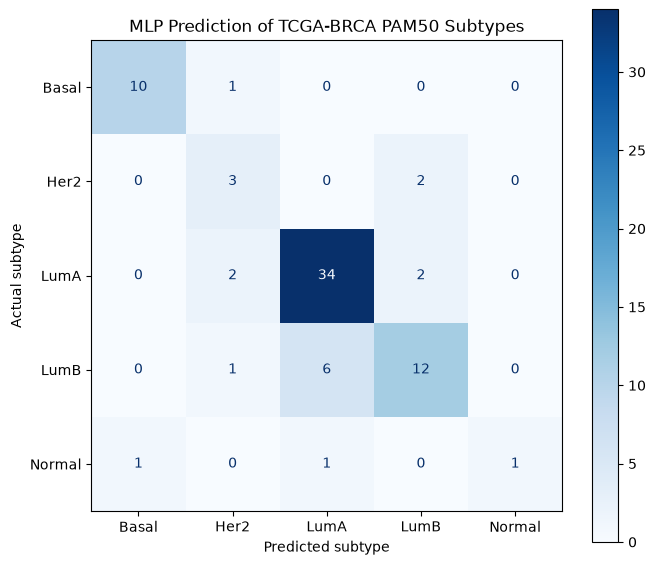

✓ Figure saved to:
C:\Users\abhij\iisc\AI-Driven-MultiOmics-Workshop\data\processed\figures\TCGA_BRCA_MLP_confusion_matrix.png


In [11]:
# ============================================================
# 7. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=np.arange(len(class_names))
)

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

ax.set_title(
    "MLP Prediction of TCGA-BRCA PAM50 Subtypes"
)

ax.set_xlabel("Predicted subtype")
ax.set_ylabel("Actual subtype")

plt.tight_layout()

confusion_path = (
    FIGURES_DIR /
    "TCGA_BRCA_MLP_confusion_matrix.png"
)

plt.savefig(
    confusion_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✓ Figure saved to:\n{confusion_path}")

In [12]:
# ============================================================
# FINAL EVALUATION — PAM50 PREDICTION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# Use the predictions already generated by the notebook
# ------------------------------------------------------------
# Expected variables:
#   y_test       = true PAM50 labels
#   y_pred       = MLP predictions
#
# If your notebook uses different variable names, change only
# the two lines below.

y_true = np.asarray(y_test)
y_pred_final = np.asarray(y_pred)

# ------------------------------------------------------------
# Core metrics
# ------------------------------------------------------------

accuracy = accuracy_score(y_true, y_pred_final)
balanced_acc = balanced_accuracy_score(y_true, y_pred_final)
macro_f1 = f1_score(y_true, y_pred_final, average="macro")
weighted_f1 = f1_score(y_true, y_pred_final, average="weighted")
macro_precision = precision_score(
    y_true, y_pred_final, average="macro", zero_division=0
)
macro_recall = recall_score(
    y_true, y_pred_final, average="macro", zero_division=0
)

# ------------------------------------------------------------
# Final report
# ------------------------------------------------------------

print("=" * 65)
print("NOTEBOOK 5 — FINAL PAM50 PREDICTION EVALUATION")
print("=" * 65)

print(f"\nTest-set patients       : {len(y_true)}")
print(f"Correct predictions     : {(y_true == y_pred_final).sum()}")
print(f"Accuracy                : {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"Balanced accuracy       : {balanced_acc:.4f}")
print(f"Macro precision         : {macro_precision:.4f}")
print(f"Macro recall            : {macro_recall:.4f}")
print(f"Macro F1                : {macro_f1:.4f}")
print(f"Weighted F1             : {weighted_f1:.4f}")

print("\n" + "-" * 65)
print("PER-SUBTYPE PERFORMANCE")
print("-" * 65)

print(
    classification_report(
        y_true,
        y_pred_final,
        digits=3,
        zero_division=0
    )
)

# ------------------------------------------------------------
# Save metrics
# ------------------------------------------------------------

metrics = {
    "n_test_patients": int(len(y_true)),
    "correct_predictions": int((y_true == y_pred_final).sum()),
    "accuracy": float(accuracy),
    "balanced_accuracy": float(balanced_acc),
    "macro_precision": float(macro_precision),
    "macro_recall": float(macro_recall),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
    "pam50_used_during_representation_learning": False,
    "evaluation_type": "held-out test set"
}

metrics_path = PROCESSED_DIR / "TCGA_BRCA_NB5_PAM50_prediction_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("-" * 65)
print(f"Metrics saved to:")
print(metrics_path)

print("\n✓ Notebook 5 evaluation complete.")

NOTEBOOK 5 — FINAL PAM50 PREDICTION EVALUATION

Test-set patients       : 76
Correct predictions     : 60
Accuracy                : 0.7895 (78.9%)
Balanced accuracy       : 0.6737
Macro precision         : 0.7834
Macro recall            : 0.6737
Macro F1                : 0.6911
Weighted F1             : 0.7860

-----------------------------------------------------------------
PER-SUBTYPE PERFORMANCE
-----------------------------------------------------------------
              precision    recall  f1-score   support

           0      0.909     0.909     0.909        11
           1      0.429     0.600     0.500         5
           2      0.829     0.895     0.861        38
           3      0.750     0.632     0.686        19
           4      1.000     0.333     0.500         3

    accuracy                          0.789        76
   macro avg      0.783     0.674     0.691        76
weighted avg      0.801     0.789     0.786        76

------------------------------------------

The learned multi-omics representation contains sufficient information to predict PAM50 subtype with 78.9% accuracy on a held-out test set, with particularly strong recovery of Basal and LumA samples. Performance is weaker for smaller subtypes, demonstrating the importance of class imbalance and sample size when evaluating multi-omics representations.

## 8. Interpretation

The MLP provides a simple example of supervised AI-driven multi-omics analysis.

The important workflow is:

**Three molecular layers → feature integration → neural network → subtype prediction → quantitative evaluation**

The model should be interpreted cautiously because:

- only 379 patients have PAM50 labels;
- the PAM50 classes are imbalanced;
- the test set is relatively small;
- the model uses a simple architecture and has not been optimised;
- predictive performance does not by itself establish biological causality.

The comparison with the majority-class baseline is important because a model can achieve apparently reasonable accuracy simply by favouring the most common subtype.

> **PAM50 labels were used for supervised training, so this notebook is fundamentally different from the unsupervised VAE, CCA, MOFA and patient-similarity analyses.**

> **The 238 PAM50-unlabelled patients were excluded from supervised evaluation rather than being assigned arbitrary labels.**

In [13]:
# ============================================================
# 8. SAVE FINAL RESULTS
# ============================================================

results = {
    "dataset": "TCGA-BRCA",
    "cohort": "TCGA-BRCA frozen cohort v1",
    "total_frozen_samples": int(len(cohort_meta)),
    "pam50_labelled_samples": int(len(labelled_ids)),
    "pam50_unlabelled_samples": int((~labelled_mask).sum()),
    
    "train_samples": int(len(train_ids)),
    "test_samples": int(len(test_ids)),
    
    "features": {
        "RNA": int(X_rna.shape[1]),
        "miRNA": int(X_mirna.shape[1]),
        "methylation": int(X_meth.shape[1]),
        "total": int(X_train.shape[1])
    },
    
    "pam50_classes": class_names.tolist(),
    
    "train_class_counts": {
        str(k): int(v)
        for k, v in y_train_raw.value_counts().items()
    },
    
    "test_class_counts": {
        str(k): int(v)
        for k, v in y_test_raw.value_counts().items()
    },
    
    "model": {
        "type": "MLPClassifier",
        "hidden_layer_sizes": [64],
        "activation": "relu",
        "solver": "adam",
        "alpha": 0.001,
        "learning_rate_init": 0.001,
        "early_stopping": True,
        "random_state": 42,
        "iterations": int(mlp.n_iter_)
    },
    
    "metrics": {
        "accuracy": float(accuracy),
        "balanced_accuracy": float(balanced_accuracy),
        "macro_f1": float(macro_f1),
        "majority_class_baseline_accuracy": float(baseline_accuracy)
    }
}

results_path = (
    PROCESSED_DIR /
    "TCGA_BRCA_MLP_results.json"
)

with open(results_path, "w") as f:
    json.dump(results, f, indent=2)

print("=" * 65)
print("FINAL NOTEBOOK SUMMARY")
print("=" * 65)

print(f"\nFrozen cohort       : {len(cohort_meta)}")
print(f"PAM50-labelled     : {len(labelled_ids)}")
print(f"Training samples   : {len(train_ids)}")
print(f"Test samples       : {len(test_ids)}")

print("\nIntegrated features:")
print("  RNA-seq       : 1,000")
print("  miRNA         :   300")
print("  Methylation   : 1,000")
print("  ---------------------")
print("  Total         : 2,300")

print("\nModel:")
print("  MLP: 2,300 → 64 → PAM50")

print("\nTest performance:")
print(f"  Accuracy          : {accuracy:.4f}")
print(f"  Balanced accuracy : {balanced_accuracy:.4f}")
print(f"  Macro F1          : {macro_f1:.4f}")

print("\nMajority baseline:")
print(f"  Accuracy          : {baseline_accuracy:.4f}")

print("\nOutput files:")
print(f"  Results : {results_path}")
print(f"  Figure  : {confusion_path}")

print("\n✓ Notebook 5 complete.")

FINAL NOTEBOOK SUMMARY

Frozen cohort       : 617
PAM50-labelled     : 379
Training samples   : 303
Test samples       : 76

Integrated features:
  RNA-seq       : 1,000
  miRNA         :   300
  Methylation   : 1,000
  ---------------------
  Total         : 2,300

Model:
  MLP: 2,300 → 64 → PAM50

Test performance:
  Accuracy          : 0.7895
  Balanced accuracy : 0.6737
  Macro F1          : 0.6911

Majority baseline:
  Accuracy          : 0.5000

Output files:
  Results : C:\Users\abhij\iisc\AI-Driven-MultiOmics-Workshop\data\processed\TCGA_BRCA_MLP_results.json
  Figure  : C:\Users\abhij\iisc\AI-Driven-MultiOmics-Workshop\data\processed\figures\TCGA_BRCA_MLP_confusion_matrix.png

✓ Notebook 5 complete.
